# Surface $\delta$DIC / $\delta$ALK maps: truth vs CDR tracer reconstruction

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.colors import SymLogNorm
from matplotlib.cm import ScalarMappable
from roms_tools import Grid, ROMSOutput
from plot import _add_coastlines_and_gridlines, _plot_colorbar, get_label_string, ZOOM_COORDS

In [2]:
grid_file = "roms_marbl_dic/expCTRL/pacmed12_grd.nc"
grid = Grid.from_file(grid_file, theta_s=6.0, theta_b=6.0, hc=250.0, N=100)

2026-09-14 12:54:54 - INFO - === Preparing the vertical coordinate system using N = 100, theta_s = 6.0, theta_b = 6.0, hc = 250.0 ===
2026-09-14 12:54:54 - INFO - Total time: 0.003 seconds
2026-09-14 12:54:54 - INFO - ================================================================================================


## Configuration

In [3]:
locations = {
    "VI": {
        "name": "Vancouver Island",
        "zoom_coords": ZOOM_COORDS["VI"],
    },
    "BC": {
        "name": "Baja California",
        "zoom_coords": ZOOM_COORDS["BC"],
    },
    "EC": {
        "name": "Ecuador",
        "zoom_coords": ZOOM_COORDS["EC"],
    },
    "JP": {
        "name": "Japan",
        "zoom_coords": ZOOM_COORDS["JP"],
    },
}

amp_labels = {"10": "10", "7": "100", "8": "1000"}

scenarios = {
    "dor": {
        "marbl_dir": "roms_marbl_dic",
        "ctrl_subdir": "OUTPUT_dor",
        "title": "DOR",
        "exps": {
            "JP10": {"label": r"\mathrm{J10}\!\ominus"},
            "JP7":  {"label": r"\mathrm{J100}\!\ominus"},
            "JP8":  {"label": r"\mathrm{J1000}\!\ominus"},
            "VI10": {"label": r"\mathrm{V10}\!\ominus"},
            "VI7":  {"label": r"\mathrm{V100}\!\ominus"},
            "VI8":  {"label": r"\mathrm{V1000}\!\ominus"},
            "BC10": {"label": r"\mathrm{B10}\!\ominus"},
            "BC7":  {"label": r"\mathrm{B100}\!\ominus"},
            "BC8":  {"label": r"\mathrm{B1000}\!\ominus"},
            "EC10": {"label": r"\mathrm{E10}\!\ominus"},
            "EC7":  {"label": r"\mathrm{E100}\!\ominus"},
            "EC8":  {"label": r"\mathrm{E1000}\!\ominus"},
        },
    },
    "oae": {
        "marbl_dir": "roms_marbl_alk",
        "ctrl_subdir": "OUTPUT_oae_perlmutter",
        "title": "OAE",
        "exps": {
            "JP10": {"label": r"\mathrm{J10}\!\oplus"},
            "JP7":  {"label": r"\mathrm{J100}\!\oplus"},
            "JP8":  {"label": r"\mathrm{J1000}\!\oplus"},
            "VI10": {"label": r"\mathrm{V10}\!\oplus"},
            "VI7":  {"label": r"\mathrm{V100}\!\oplus"},
            "VI8":  {"label": r"\mathrm{V1000}\!\oplus"},
            "BC10": {"label": r"\mathrm{B10}\!\oplus"},
            "BC7":  {"label": r"\mathrm{B100}\!\oplus"},
            "BC8":  {"label": r"\mathrm{B1000}\!\oplus"},
            "EC10": {"label": r"\mathrm{E10}\!\oplus"},
            "EC7":  {"label": r"\mathrm{E100}\!\oplus"},
            "EC8":  {"label": r"\mathrm{E1000}\!\oplus"},
        },
    },
}

## Load data

In [4]:
def load_scenario(date, scenario_key, loc_keys=None, amps=None):
    scen = scenarios[scenario_key]
    if loc_keys is None:
        loc_keys = list(locations.keys())
    if amps is None:
        amps = ["10", "7", "8"]

    ctrl_output = ROMSOutput(
        grid=grid,
        path=f"roms/exp0/{scen['ctrl_subdir']}/JOINED/pacmed_his.{date}*.nc",
        use_dask=True
    )

    marbl_data = {}
    for loc in loc_keys:
        for amp in amps:
            exp = f"{loc}{amp}"
            # roms_marbl_alk's amp=8 site dirs are currently named exp<SITE>8_perlmutter
            # (Anvil-sourced copies without the suffix aren't reliable yet).
            suffix = "_perlmutter" if scen["marbl_dir"] == "roms_marbl_alk" and amp == "8" else ""
            roms_output = ROMSOutput(
                grid=grid,
                path=f"{scen['marbl_dir']}/exp{exp}{suffix}/OUTPUT/JOINED/pacmed_bgc.{date}*.nc",
                use_dask=True
            )
            marbl_data[exp] = roms_output.ds

    return ctrl_output.ds, marbl_data

In [5]:
kwargs_diff_override={
    "JP10": dict(vmin=-0.00005, vmax=0.00005, cmap="RdBu_r"), 
    "JP8": dict(vmin=-0.03, vmax=0.03, cmap="RdBu_r"),
    "VI10": dict(vmin=-0.0005, vmax=0.0005, cmap="RdBu_r"), 
    "VI8": dict(vmin=-3, vmax=3, cmap="RdBu_r"),
    "EC10": dict(vmin=-0.0001, vmax=0.0001, cmap="RdBu_r"), 
    "EC8": dict(vmin=-0.3, vmax=0.3, cmap="RdBu_r"),
    "BC10": dict(vmin=-0.0001, vmax=0.0001, cmap="RdBu_r"), 
    "BC8": dict(vmin=-0.2, vmax=0.2, cmap="RdBu_r")
}

## Core functions

In [6]:
def compute_deltas(ctrl_ds, marbl_data, exp, cdr_type="dor", tracer="dic"):
    s_rho = -1
    ds = marbl_data[exp]

    if cdr_type == "dor":
        delta_truth = (ds.DIC - ds.DIC_ALT_CO2).isel(s_rho=s_rho).squeeze().compute()
        delta_recon = (-ctrl_ds[f"{exp}_DEFICIT"]).isel(s_rho=s_rho).squeeze().compute()
    elif cdr_type == "oae" and tracer == "dic":
        delta_truth = (ds.DIC - ds.DIC_ALT_CO2).isel(s_rho=s_rho).squeeze().compute()
        delta_recon = (-ctrl_ds[f"{exp}_OAE_DEF"]).isel(s_rho=s_rho).squeeze().compute()
    elif cdr_type == "oae" and tracer == "alk":
        delta_truth = (ds.ALK - ds.ALK_ALT_CO2).isel(s_rho=s_rho).squeeze().compute()
        delta_recon = ctrl_ds[f"{exp}_CONSERVED"].isel(s_rho=s_rho).squeeze().compute()

    return delta_truth, delta_recon


def auto_kwargs(delta_truth, delta_recon, diff, log_decades=1, log_scale=True):
    data_min = min(float(delta_truth.min(skipna=True)),
                   float(delta_recon.min(skipna=True)))
    data_max = max(float(delta_truth.max(skipna=True)),
                   float(delta_recon.max(skipna=True)))

    abs_max = max(abs(data_min), abs(data_max))
    if abs_max == 0:
        abs_max = 1.0

    cmap = "BuGn_r" if abs(data_min) > abs(data_max) else "BuGn"

    if log_scale:
        linthresh = 10 ** max(-10, np.floor(np.log10(abs_max)) - log_decades)
        if cmap == "BuGn_r":
            norm = SymLogNorm(linthresh=linthresh, vmin=data_min, vmax=0)
        else:
            norm = SymLogNorm(linthresh=linthresh, vmin=0, vmax=data_max)
        kwargs_field = {"norm": norm, "cmap": cmap}
    else:
        if cmap == "BuGn_r":
            kwargs_field = {"vmin": data_min, "vmax": 0, "cmap": cmap}
        else:
            kwargs_field = {"vmin": 0, "vmax": data_max, "cmap": cmap}

    diff_max = float(np.abs(diff).max(skipna=True))
    if diff_max == 0:
        diff_max = 1.0
    kwargs_diff = {"vmin": -diff_max, "vmax": diff_max, "cmap": "RdBu_r"}

    return kwargs_field, kwargs_diff


def get_panel_titles(exp, cdr_type, tracer="dic", relative=False):
    label = scenarios[cdr_type]["exps"][exp]["label"]
    if tracer == "alk":
        var = r"\mathrm{ALK}"
    else:
        var = r"\mathrm{DIC}"


    diff_label = rf"${label}$: $c_{{\delta {var}}} - \delta {var}$"

    return (
        rf"${label}$: $\delta {var}$ (truth)",
        rf"${label}$: $c_{{\delta {var}}}$ (CDR tracer)",
        diff_label,
    )


def plot_map_panel(fig, ax, lon, lat, data, zoom_coords, kwargs_plot,
                   shrink=0.7, pad=0.15, vpos=0.05, title=""):
    mask = grid.ds.mask_rho
    p = ax.pcolormesh(lon, lat, data.where(mask),
                      transform=ccrs.PlateCarree(), **kwargs_plot)
    _plot_colorbar(fig, ax, p, data,
                   kwargs_plot.get("vmax"), kwargs_plot.get("vmin"),
                   label=r"mmol/m$^3$", shrink=shrink, pad=pad)
    label_string = get_label_string(data)
    ax.text(0.5, vpos, label_string,
            transform=ax.transAxes, ha="center", va="center")
    if title:
        ax.set_title(title)
    _add_coastlines_and_gridlines(
        ax, zoom_coords["lon_min"], zoom_coords["lon_max"],
        zoom_coords["lat_min"], zoom_coords["lat_max"],
    )

## Truth vs. difference summary (2$\times$3)

Top row: $\delta$ tracer (truth). Bottom row: CDR tracer $-$ truth.
Columns: $\delta$ALK for VI, $\delta$DIC for VI, $\delta$DIC for JP (OAE, amp `8`).
Each column is plotted in its own regional projection.

In [7]:
def plot_truth_diff_summary(ctrl_ds, marbl_data, columns, amp="8", cdr_type="oae",
                            kwargs_field_list=None, kwargs_diff_list=None,
                            log_decades=2, log_scale=True,
                            figsize=(13, 8), shrink=0.8, pad=0.12, vpos=0.05,
                            panel_labels=("a", "b", "c", "d", "e", "f")):
    """2 x len(columns) panel: top row = delta tracer (truth), bottom row = CDR tracer - truth.

    Each column is a (loc_key, tracer) pair plotted in its own regional projection, so columns
    can freely mix sites and tracers (e.g. [("VI", "alk"), ("VI", "dic"), ("JP", "dic")]).
    kwargs_field_list / kwargs_diff_list, when given, are per-column dicts (or None) overriding
    the auto colorbar for that column's truth / difference panel. panel_labels are applied in
    row-major order (a b c / d e f); pass None to omit.
    """
    lon, lat = grid.ds["lon_rho"], grid.ds["lat_rho"]
    ncol = len(columns)
    kwargs_field_list = kwargs_field_list or [None] * ncol
    kwargs_diff_list = kwargs_diff_list or [None] * ncol
    labels = list(panel_labels) if panel_labels else [None] * (2 * ncol)

    fig = plt.figure(figsize=figsize)
    for j, (loc_key, tracer) in enumerate(columns):
        zoom = locations[loc_key]["zoom_coords"]
        proj = ccrs.LambertConformal(
            central_longitude=(zoom["lon_min"] + zoom["lon_max"]) / 2,
            central_latitude=(zoom["lat_min"] + zoom["lat_max"]) / 2,
        )

        exp = f"{loc_key}{amp}"
        delta_truth, delta_recon = compute_deltas(ctrl_ds, marbl_data, exp, cdr_type, tracer)
        diff = delta_recon - delta_truth

        kf, kd = auto_kwargs(delta_truth, delta_recon, diff,
                             log_decades=log_decades, log_scale=log_scale)
        if kwargs_field_list[j] is not None:
            kf = kwargs_field_list[j]
        if kwargs_diff_list[j] is not None:
            kd = kwargs_diff_list[j]

        var = r"\mathrm{ALK}" if tracer == "alk" else r"\mathrm{DIC}"
        label = scenarios[cdr_type]["exps"][exp]["label"]
        row_panels = [
            (delta_truth, kf, rf"${label}$: $\delta {var}$ (truth)"),
            (diff, kd, rf"${label}$: $c_{{\delta {var}}} - \delta {var}$"),
        ]
        for i, (data, kw, title) in enumerate(row_panels):
            k = i * ncol + j
            ax = fig.add_subplot(2, ncol, k + 1, projection=proj)
            if labels[k]:
                title = f"({labels[k]}) {title}"
            plot_map_panel(fig, ax, lon, lat, data, zoom, kw,
                           shrink=shrink, pad=pad, vpos=vpos, title=title)

    plt.tight_layout()
    return fig

In [8]:
date = "20000701"

dor_ctrl, dor_marbl = load_scenario(date, "dor")
oae_ctrl, oae_marbl = load_scenario(date, "oae")

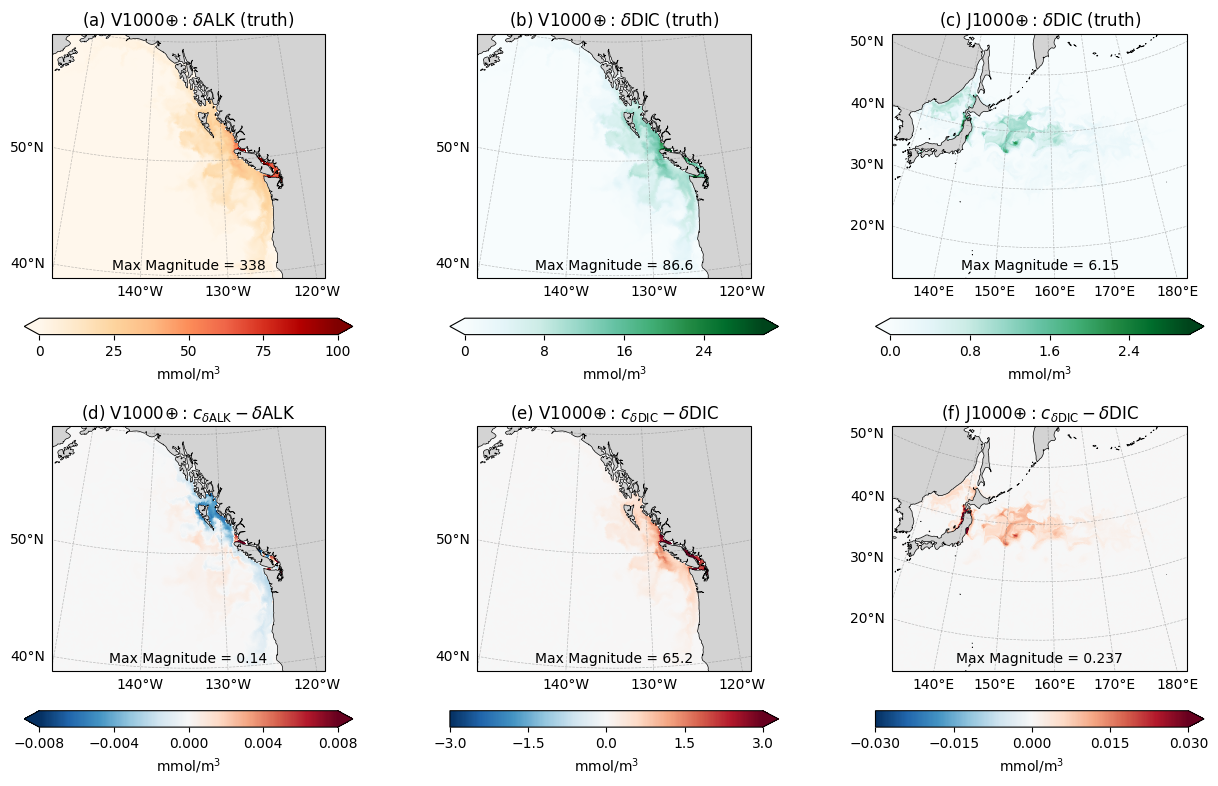

In [9]:
fig = plot_truth_diff_summary(
    oae_ctrl, oae_marbl,
    columns=[("VI", "alk"), ("VI", "dic"), ("JP", "dic")],
    cdr_type="oae", amp="8",
    log_scale=False,  # truth (top row) on a linear scale
    kwargs_field_list=[
        dict(vmin=0, vmax=100, cmap="OrRd"),  # VI: delta ALK
        dict(vmin=0, vmax=30, cmap="BuGn"),          # VI: delta DIC
        dict(vmin=0, vmax=3, cmap="BuGn"),    # JP: delta DIC
    ],
    kwargs_diff_list=[
        dict(vmin=-0.008, vmax=0.008, cmap="RdBu_r"),  # VI: delta ALK
        dict(vmin=-3, vmax=3, cmap="RdBu_r"),          # VI: delta DIC
        dict(vmin=-0.03, vmax=0.03, cmap="RdBu_r"),    # JP: delta DIC
    ],
)
fig.savefig(f"figures/deltadic_deltaalk_truth_diff_VI_JP_{date}.png", dpi=300, bbox_inches="tight")

## Amplitude sweep: truth vs. error (2$\times$3)

For a single location, one figure per (scenario, tracer):

* **Row 1** – $\delta$ tracer (truth) for amplitudes 10 / 100 / 1000 (`amp` = `10` / `7` / `8`).
* **Row 2** – error $c_{\delta\,\mathrm{tracer}} - \delta\,\mathrm{tracer}$ (CDR tracer $-$ truth).

Pick the location with the `loc_key` argument (`"JP"`, `"VI"`, `"BC"`, `"EC"`). All
three columns share that location's regional projection. Pass `kwargs_field_list` /
`kwargs_diff_list` (3 per-column dicts, or `None`) to override the auto colorbars,
since the amplitude columns span ~2 orders of magnitude.

In [9]:
def plot_amp_truth_diff_summary(ctrl_ds, marbl_data, loc_key,
                                cdr_type="oae", tracer="alk", amps=("10", "7", "8"),
                                kwargs_field_list=None, kwargs_diff_list=None,
                                log_decades=2, log_scale=False,
                                figsize=(13, 8), shrink=0.8, pad=0.12, vpos=0.05,
                                panel_labels=("a", "b", "c", "d", "e", "f"),
                                date=None):
    """2 x len(amps) panel for a single location.

    Top row: delta tracer (truth) for each amplitude.
    Bottom row: error = CDR tracer - truth, for each amplitude.
    Columns are amplitudes (default 10 / 100 / 1000, i.e. amp = 10 / 7 / 8); all
    columns share the location's regional projection. kwargs_field_list /
    kwargs_diff_list, when given, are per-column dicts (or None) overriding the
    auto colorbar for that amplitude's truth / error panel. panel_labels are
    applied in row-major order (a b c / d e f); pass None to omit.
    """
    lon, lat = grid.ds["lon_rho"], grid.ds["lat_rho"]
    ncol = len(amps)
    kwargs_field_list = kwargs_field_list or [None] * ncol
    kwargs_diff_list = kwargs_diff_list or [None] * ncol
    labels = list(panel_labels) if panel_labels else [None] * (2 * ncol)

    zoom = locations[loc_key]["zoom_coords"]
    proj = ccrs.LambertConformal(
        central_longitude=(zoom["lon_min"] + zoom["lon_max"]) / 2,
        central_latitude=(zoom["lat_min"] + zoom["lat_max"]) / 2,
    )

    fig = plt.figure(figsize=figsize)
    for j, amp in enumerate(amps):
        exp = f"{loc_key}{amp}"
        delta_truth, delta_recon = compute_deltas(ctrl_ds, marbl_data, exp, cdr_type, tracer)
        diff = delta_recon - delta_truth

        kf, kd = auto_kwargs(delta_truth, delta_recon, diff,
                             log_decades=log_decades, log_scale=log_scale)
        if kwargs_field_list[j] is not None:
            kf = kwargs_field_list[j]
        if kwargs_diff_list[j] is not None:
            kd = kwargs_diff_list[j]

        var = r"\mathrm{ALK}" if tracer == "alk" else r"\mathrm{DIC}"
        label = scenarios[cdr_type]["exps"][exp]["label"]
        col_panels = [
            (delta_truth, kf, rf"${label}$: $\delta {var}$ (truth)"),
            (diff, kd, rf"${label}$: $c_{{\delta {var}}} - \delta {var}$"),
        ]
        for i, (data, kw, title) in enumerate(col_panels):
            k = i * ncol + j
            ax = fig.add_subplot(2, ncol, k + 1, projection=proj)
            if labels[k]:
                title = f"({labels[k]}) {title}"
            plot_map_panel(fig, ax, lon, lat, data, zoom, kw,
                           shrink=shrink, pad=pad, vpos=vpos, title=title)

    if date is not None:
        from datetime import datetime
        date_str = datetime.strptime(date, "%Y%m%d").strftime("%-d %B %Y")
        fig.suptitle(date_str, y=1.01)
    plt.tight_layout()
    return fig

## July 1, 2000

In [10]:
date = "20000701"

dor_ctrl, dor_marbl = load_scenario(date, "dor")
oae_ctrl, oae_marbl = load_scenario(date, "oae")

### delta ALK, OAE

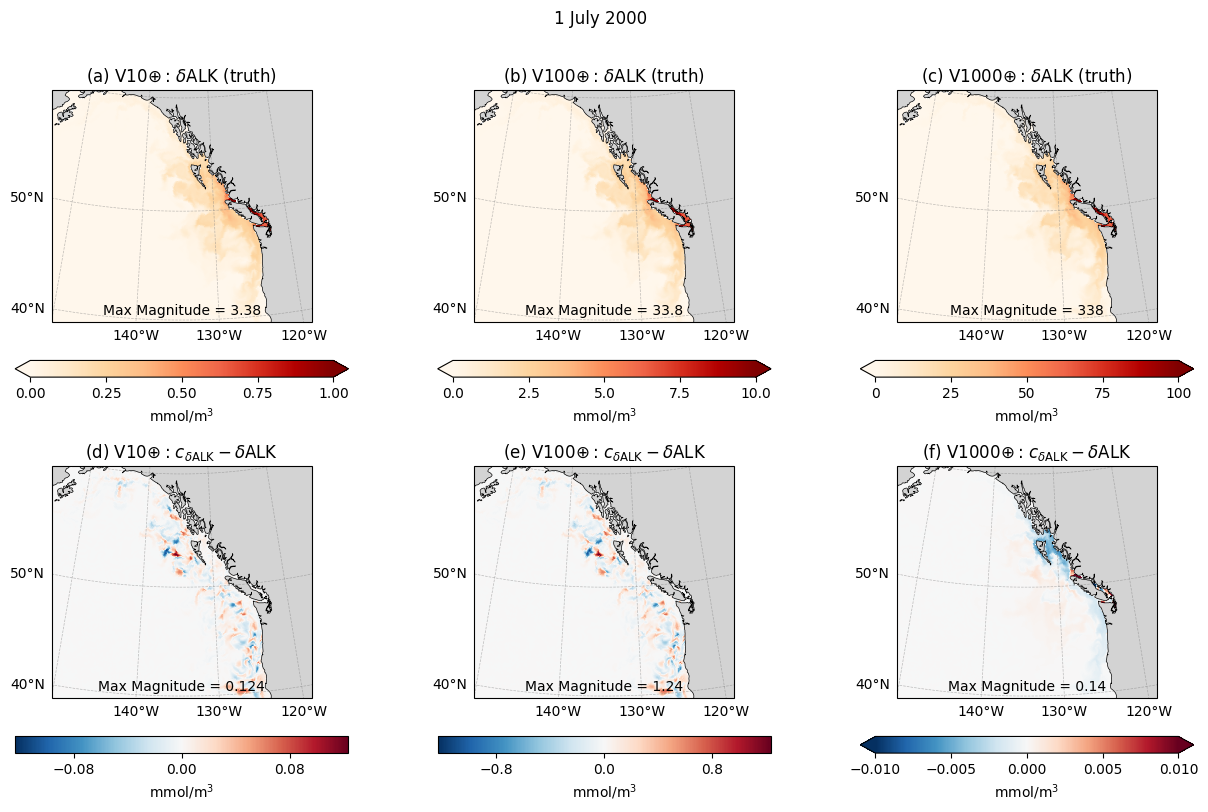

In [11]:
loc_key = "VI"

fig = plot_amp_truth_diff_summary(
    oae_ctrl, oae_marbl, loc_key,
    cdr_type="oae", tracer="alk",
    date=date,
    kwargs_field_list=[
        dict(vmin=0, vmax=1, cmap="OrRd"), 
        dict(vmin=0, vmax=10, cmap="OrRd"), 
        dict(vmin=0, vmax=100, cmap="OrRd"), 
    ],
    kwargs_diff_list=[
        None,
        None,
        dict(vmin=-0.01, vmax=0.01, cmap="RdBu_r"),
    ],
)
fig.savefig(f"figures/deltaalk_oae_amp_truth_diff_{loc_key}_{date}.png", dpi=300, bbox_inches="tight")

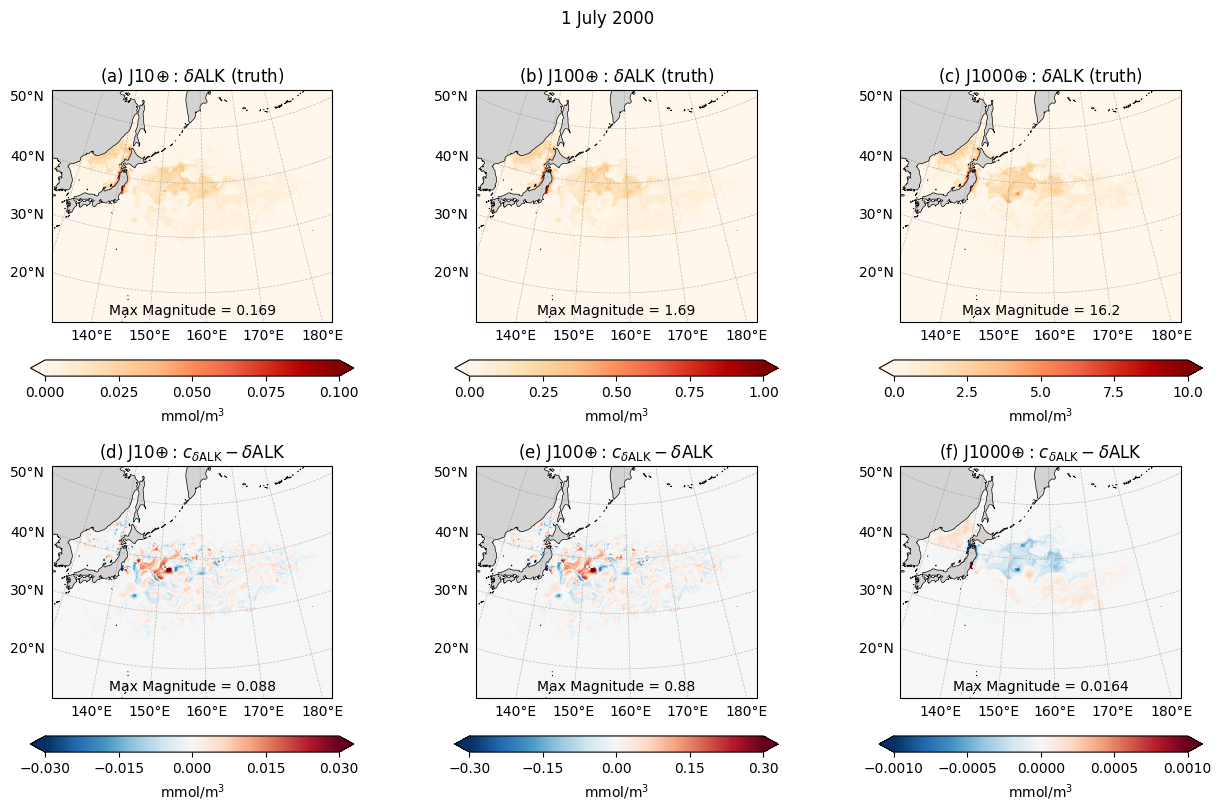

In [12]:
loc_key = "JP"

fig = plot_amp_truth_diff_summary(
    oae_ctrl, oae_marbl, loc_key,
    cdr_type="oae", tracer="alk",
    date=date,
    kwargs_field_list=[
        dict(vmin=0, vmax=0.1, cmap="OrRd"), 
        dict(vmin=0, vmax=1, cmap="OrRd"), 
        dict(vmin=0, vmax=10, cmap="OrRd"), 
    ],
    kwargs_diff_list=[
        dict(vmin=-0.03, vmax=0.03, cmap="RdBu_r"),
        dict(vmin=-0.3, vmax=0.3, cmap="RdBu_r"),
        dict(vmin=-0.001, vmax=0.001, cmap="RdBu_r"),
    ],
)
fig.savefig(f"figures/deltaalk_oae_amp_truth_diff_{loc_key}_{date}.png", dpi=300, bbox_inches="tight")

### delta DIC, OAE

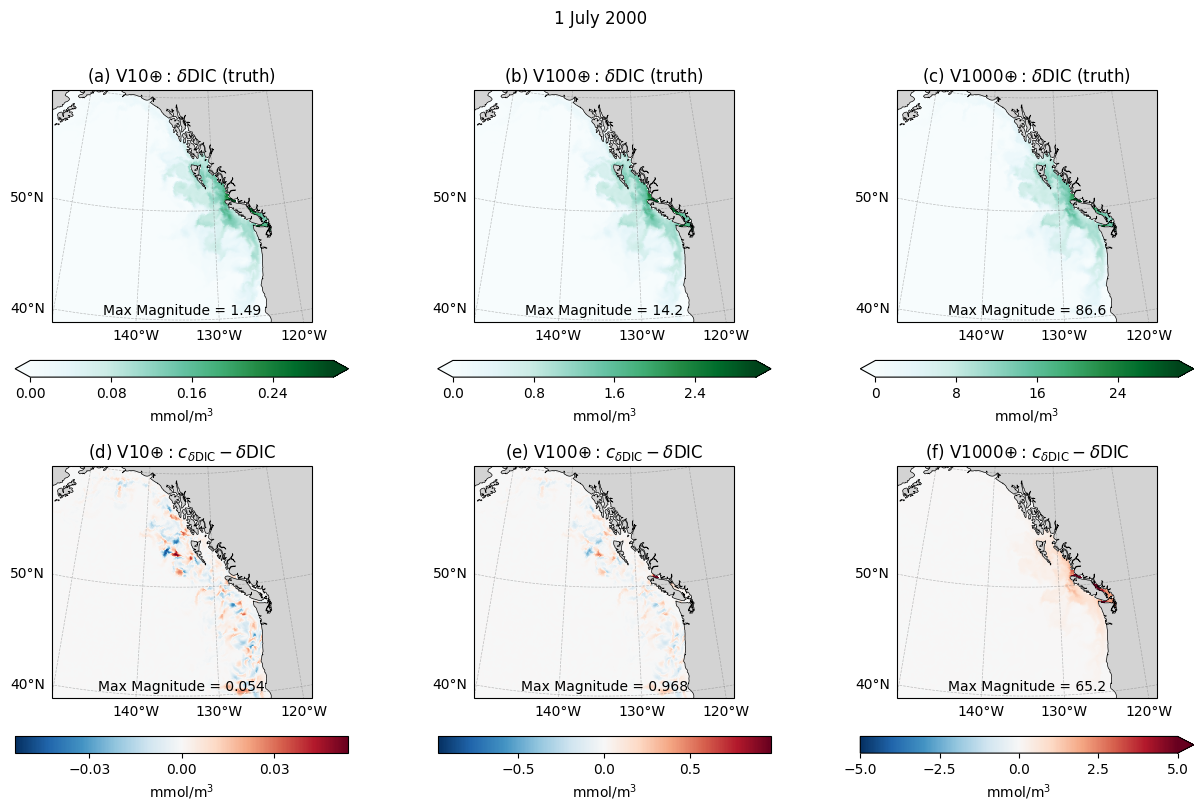

In [13]:
loc_key = "VI"

fig = plot_amp_truth_diff_summary(
    oae_ctrl, oae_marbl, loc_key,
    cdr_type="oae", tracer="dic",
    date=date,
    kwargs_field_list=[
        dict(vmin=0, vmax=0.3, cmap="BuGn"), 
        dict(vmin=0, vmax=3, cmap="BuGn"), 
        dict(vmin=0, vmax=30, cmap="BuGn"), 
    ],
    kwargs_diff_list=[
        None,
        None,
        dict(vmin=-5, vmax=5, cmap="RdBu_r"),
    ],
)
fig.savefig(f"figures/deltadic_oae_amp_truth_diff_{loc_key}_{date}.png", dpi=300, bbox_inches="tight")

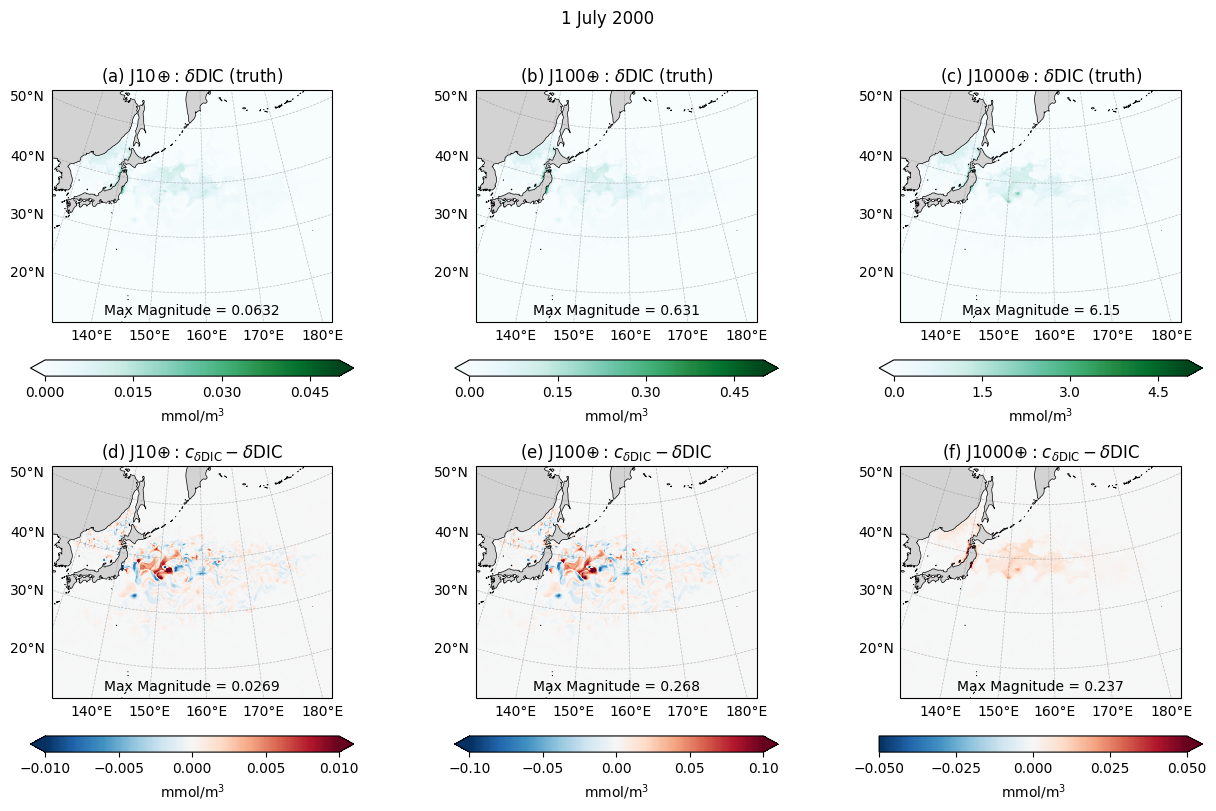

In [14]:
loc_key = "JP"

fig = plot_amp_truth_diff_summary(
    oae_ctrl, oae_marbl, loc_key,
    cdr_type="oae", tracer="dic",
    date=date,
    kwargs_field_list=[
        dict(vmin=0, vmax=0.05, cmap="BuGn"), 
        dict(vmin=0, vmax=0.5, cmap="BuGn"), 
        dict(vmin=0, vmax=5, cmap="BuGn"), 
    ],
    kwargs_diff_list=[
        dict(vmin=-0.01, vmax=0.01, cmap="RdBu_r"),
        dict(vmin=-0.1, vmax=0.1, cmap="RdBu_r"),
        dict(vmin=-0.05, vmax=0.05, cmap="RdBu_r"),
    ],
)
fig.savefig(f"figures/deltadic_oae_amp_truth_diff_{loc_key}_{date}.png", dpi=300, bbox_inches="tight")

### deltaDIC, DOR

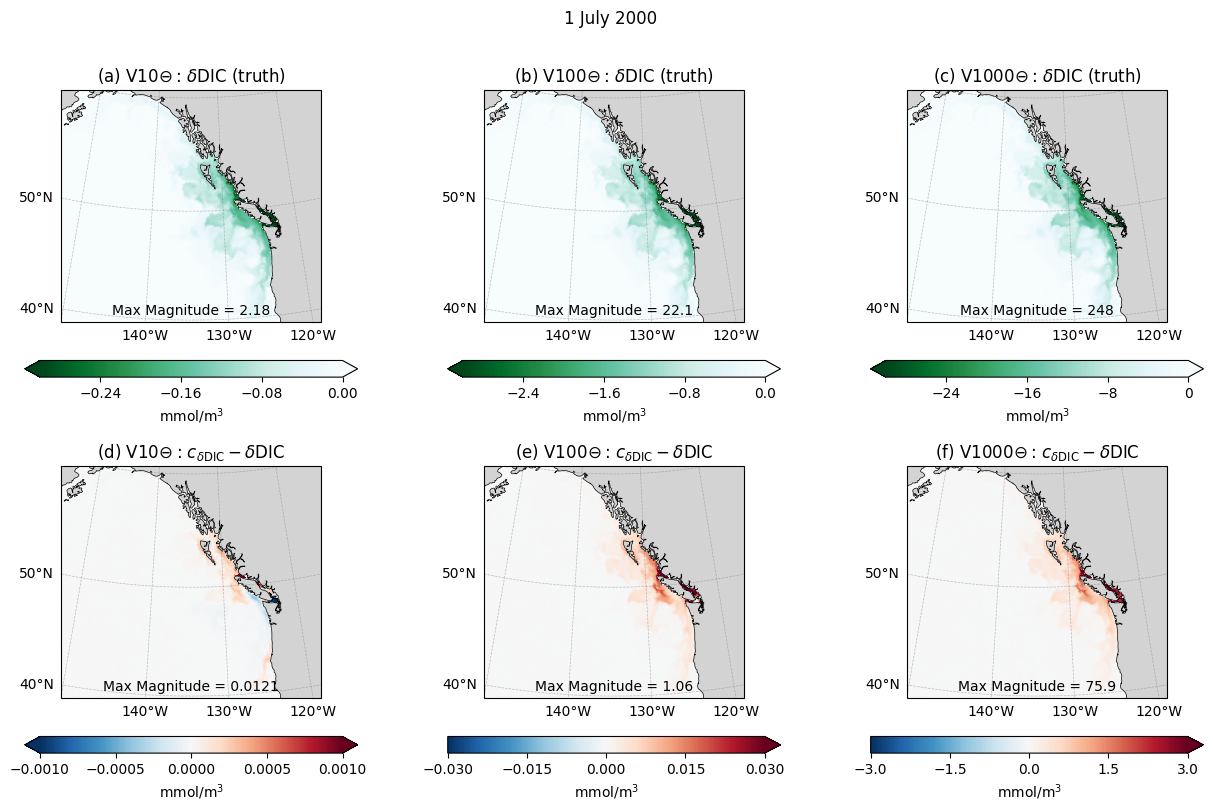

In [15]:
loc_key = "VI"

fig = plot_amp_truth_diff_summary(
    dor_ctrl, dor_marbl, loc_key,
    cdr_type="dor", tracer="dic",
    date=date,
        kwargs_field_list=[
        dict(vmin=-0.3, vmax=0, cmap="BuGn_r"), 
        dict(vmin=-3, vmax=0, cmap="BuGn_r"), 
        dict(vmin=-30, vmax=0, cmap="BuGn_r"), 
    ],
    kwargs_diff_list=[
        dict(vmin=-0.001, vmax=0.001, cmap="RdBu_r"),
        dict(vmin=-0.03, vmax=0.03, cmap="RdBu_r"),
        dict(vmin=-3, vmax=3, cmap="RdBu_r"),
    ],
)
fig.savefig(f"figures/deltadic_dor_amp_truth_diff_{loc_key}_{date}.png", dpi=300, bbox_inches="tight")

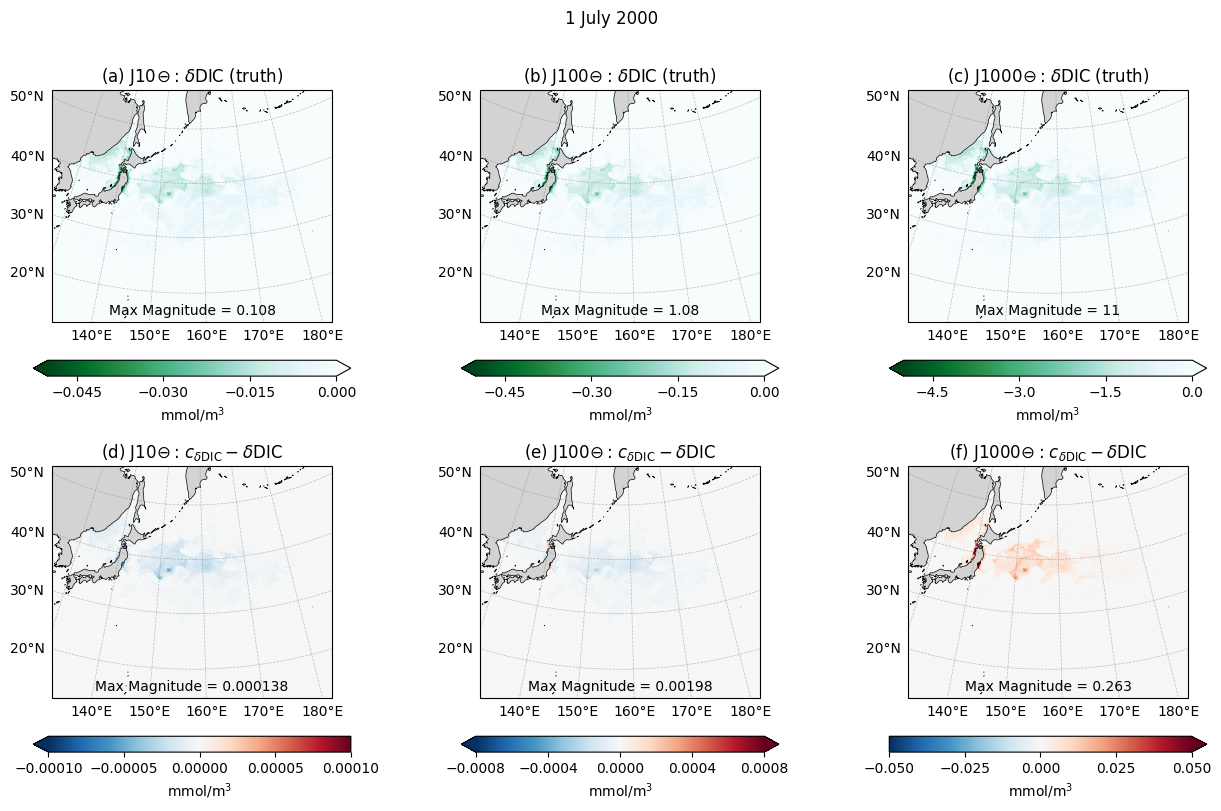

In [16]:
loc_key = "JP"

fig = plot_amp_truth_diff_summary(
    dor_ctrl, dor_marbl, loc_key,
    cdr_type="dor", tracer="dic",
    date=date,
        kwargs_field_list=[
        dict(vmin=-0.05, vmax=0, cmap="BuGn_r"), 
        dict(vmin=-0.5, vmax=0, cmap="BuGn_r"), 
        dict(vmin=-5, vmax=0, cmap="BuGn_r"), 
    ],
    kwargs_diff_list=[
        dict(vmin=-0.0001, vmax=0.0001, cmap="RdBu_r"),
        dict(vmin=-0.0008, vmax=0.0008, cmap="RdBu_r"),
        dict(vmin=-0.05, vmax=0.05, cmap="RdBu_r"),
    ],
)
fig.savefig(f"figures/deltadic_dor_amp_truth_diff_{loc_key}_{date}.png", dpi=300, bbox_inches="tight")

## December 31, 2001

In [17]:
date = "20011231"

dor_ctrl, dor_marbl = load_scenario(date, "dor")
#oae_ctrl, oae_marbl = load_scenario(date, "oae")

### deltaDIC, DOR

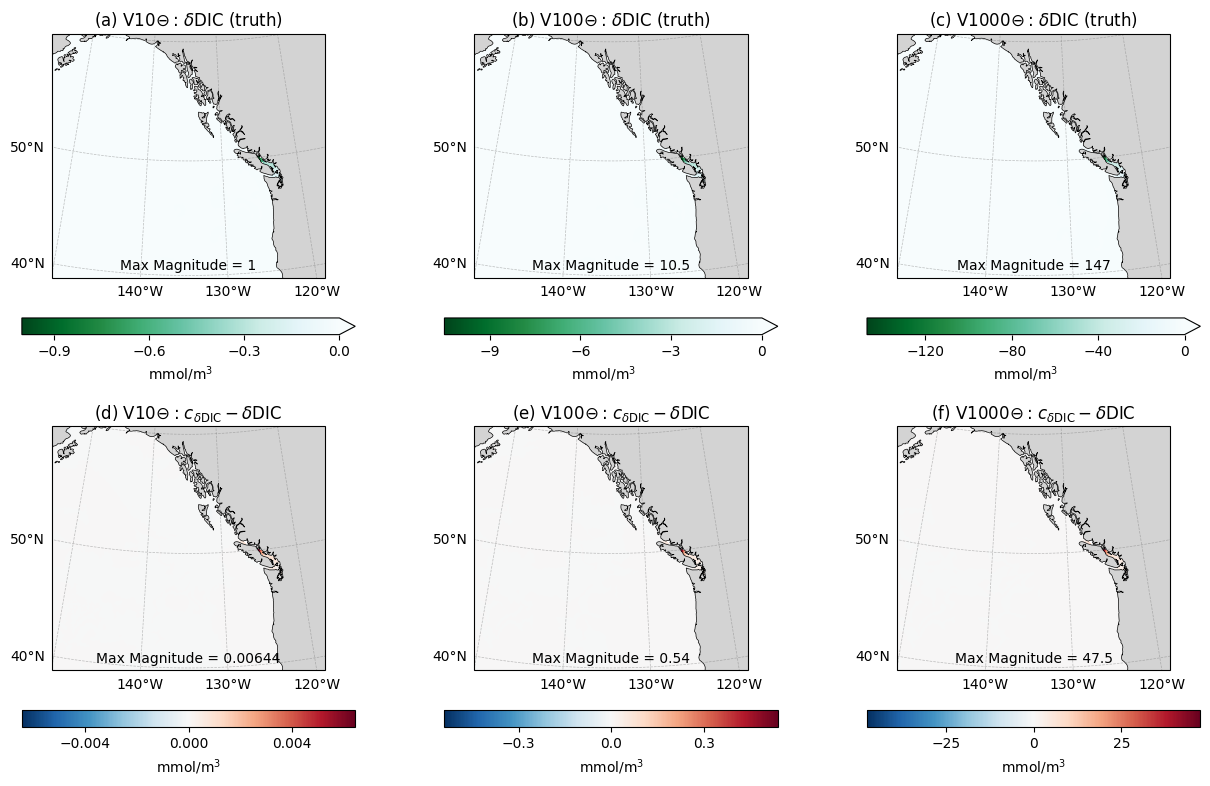

In [18]:
loc_key = "VI"

fig = plot_amp_truth_diff_summary(
    dor_ctrl, dor_marbl, loc_key,
    cdr_type="dor", tracer="dic",
)
fig.savefig(f"figures/deltadic_dor_amp_truth_diff_{loc_key}_{date}.png", dpi=300, bbox_inches="tight")

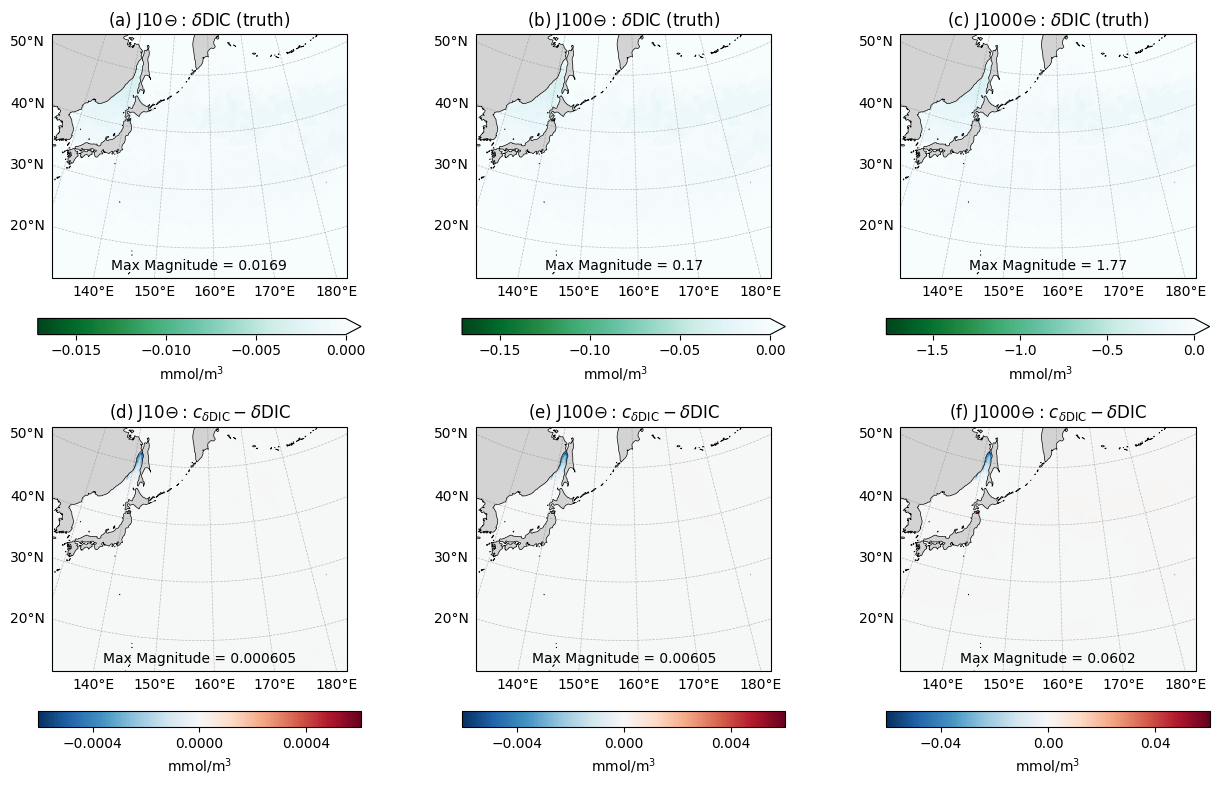

In [19]:
loc_key = "JP"

fig = plot_amp_truth_diff_summary(
    dor_ctrl, dor_marbl, loc_key,
    cdr_type="dor", tracer="dic",
)
fig.savefig(f"figures/deltadic_dor_amp_truth_diff_{loc_key}_{date}.png", dpi=300, bbox_inches="tight")

## Single location, single amplitude (1$\times$3)

Same as `plot_amp_panel`, but for a single `amp` (not a list), giving one row of
truth / CDR tracer / difference. Panel titles are prefixed with `(a)`/`(b)`/`(c)`
by default; pass `panel_labels=("d", "e", "f")` (or any 3 labels) to change them.

In [20]:
def plot_single_amp_panel(ctrl_ds, marbl_data, loc_key, amp,
                          cdr_type="dor", tracer="dic",
                          kwargs_diff_override=kwargs_diff_override,
                          kwargs_field_override=None,
                          log_decades=2, log_scale=True,
                          figsize=(12, 4), shrink=0.8, pad=0.12, vpos=0.05,
                          panel_labels=("a", "b", "c")):
    lon, lat = grid.ds["lon_rho"], grid.ds["lat_rho"]
    zoom = locations[loc_key]["zoom_coords"]

    proj = ccrs.LambertConformal(
        central_longitude=(zoom["lon_min"] + zoom["lon_max"]) / 2,
        central_latitude=(zoom["lat_min"] + zoom["lat_max"]) / 2,
    )

    fig, axs = plt.subplots(1, 3, figsize=figsize,
                            subplot_kw={"projection": proj})

    exp = f"{loc_key}{amp}"
    delta_truth, delta_recon = compute_deltas(
        ctrl_ds, marbl_data, exp, cdr_type, tracer
    )

    diff = delta_recon - delta_truth
        
    kwargs_field, kwargs_diff = auto_kwargs(delta_truth, delta_recon, diff,
                                            log_decades=log_decades, log_scale=log_scale)
    if not log_scale and kwargs_field_override and exp in kwargs_field_override:
        kwargs_field = kwargs_field_override[exp]
    if kwargs_diff_override and exp in kwargs_diff_override:
        kwargs_diff = kwargs_diff_override[exp]

    titles = get_panel_titles(exp, cdr_type, tracer)
    if panel_labels:
        titles = tuple(f"({label}) {title}" for label, title in zip(panel_labels, titles))

    panels = [
        (delta_truth, kwargs_field, titles[0]),
        (delta_recon, kwargs_field, titles[1]),
        (diff, kwargs_diff, titles[2]),
    ]

    for j, (data, kw, title) in enumerate(panels):
        plot_map_panel(fig, axs[j], lon, lat, data, zoom, kw,
                       shrink=shrink, pad=pad, vpos=vpos, title=title)

    plt.tight_layout()
    return fig

### OAE, DIC

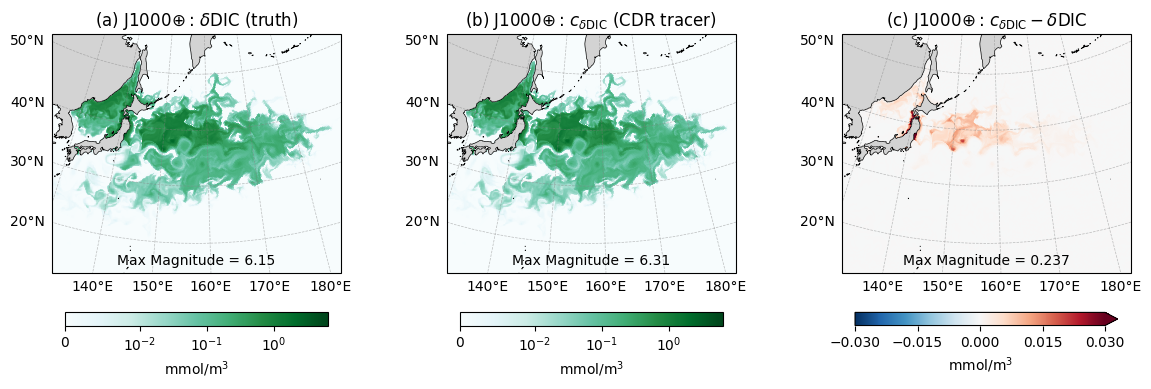

In [21]:
fig = plot_single_amp_panel(
    oae_ctrl, oae_marbl, "JP", "8",
    cdr_type="oae", tracer="dic",
)

In [22]:
fig.savefig("figures/deltadic_oae_J1000.png", dpi=300, bbox_inches="tight")

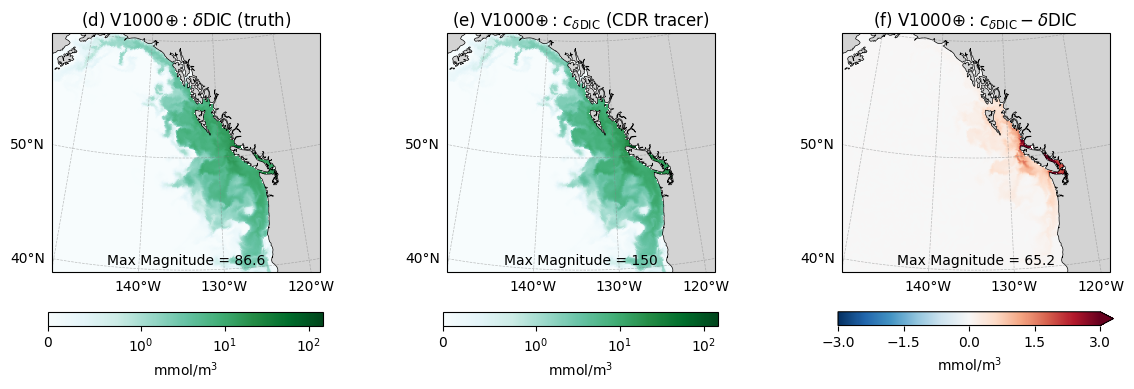

In [23]:
fig = plot_single_amp_panel(
    oae_ctrl, oae_marbl, "VI", "8",
    cdr_type="oae", tracer="dic",
    panel_labels=("d", "e", "f")
)

In [24]:
fig.savefig("figures/deltadic_oae_V1000.png", dpi=300, bbox_inches="tight")

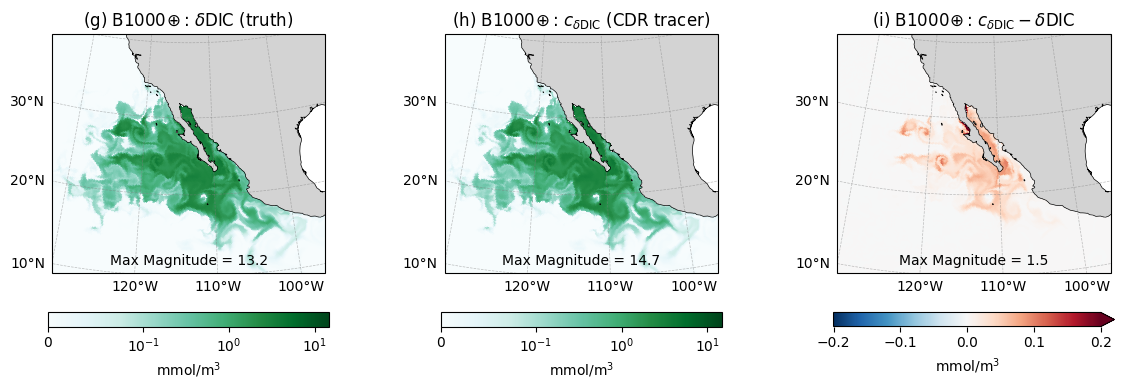

In [25]:
fig = plot_single_amp_panel(
    oae_ctrl, oae_marbl, "BC", "8",
    cdr_type="oae", tracer="dic",
    panel_labels=("g", "h", "i")
)

In [26]:
fig.savefig("figures/deltadic_oae_B1000.png", dpi=300, bbox_inches="tight")

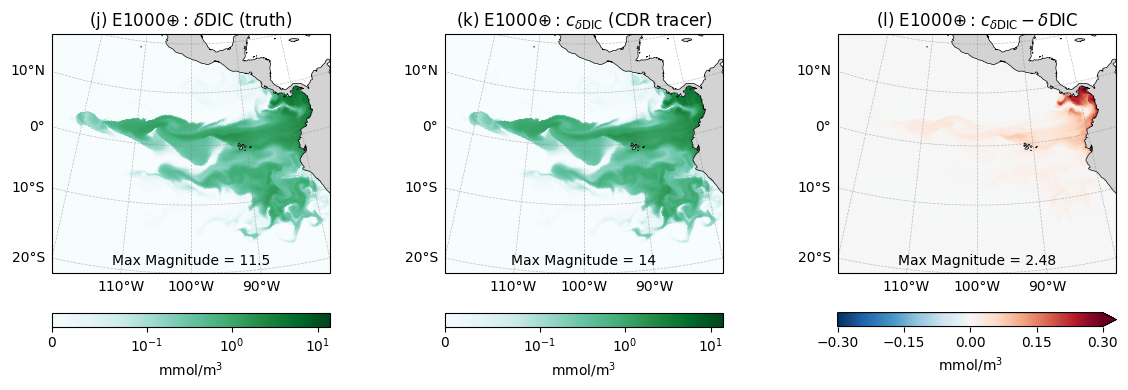

In [27]:
fig = plot_single_amp_panel(
    oae_ctrl, oae_marbl, "EC", "8",
    cdr_type="oae", tracer="dic",
    panel_labels=("j", "k", "l")
)

In [28]:
fig.savefig("figures/deltadic_oae_E1000.png", dpi=300, bbox_inches="tight")

### DOR, DIC

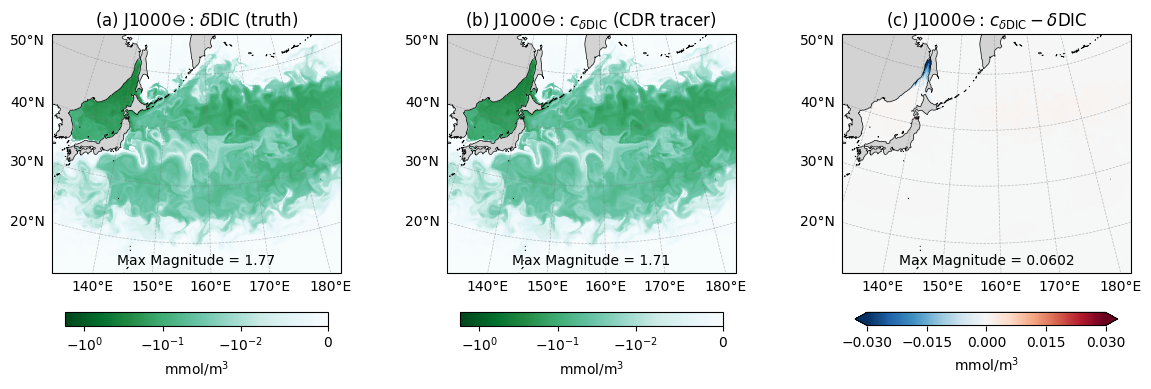

In [29]:
fig = plot_single_amp_panel(
    dor_ctrl, dor_marbl, "JP", "8",
    cdr_type="dor", tracer="dic",
)

In [30]:
fig.savefig("figures/deltadic_dor_J1000.png", dpi=300, bbox_inches="tight")

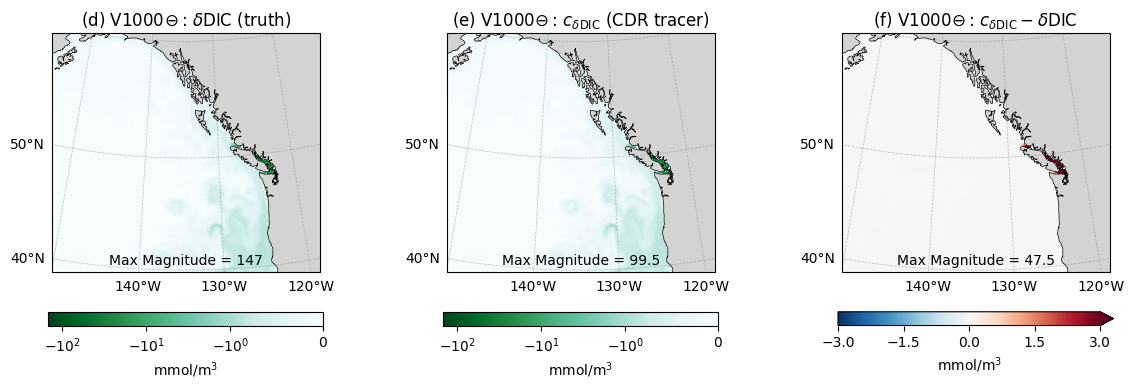

In [31]:
fig = plot_single_amp_panel(
    dor_ctrl, dor_marbl, "VI", "8",
    cdr_type="dor", tracer="dic",
    panel_labels=("d", "e", "f")
)

In [32]:
fig.savefig("figures/deltadic_dor_V1000.png", dpi=300, bbox_inches="tight")

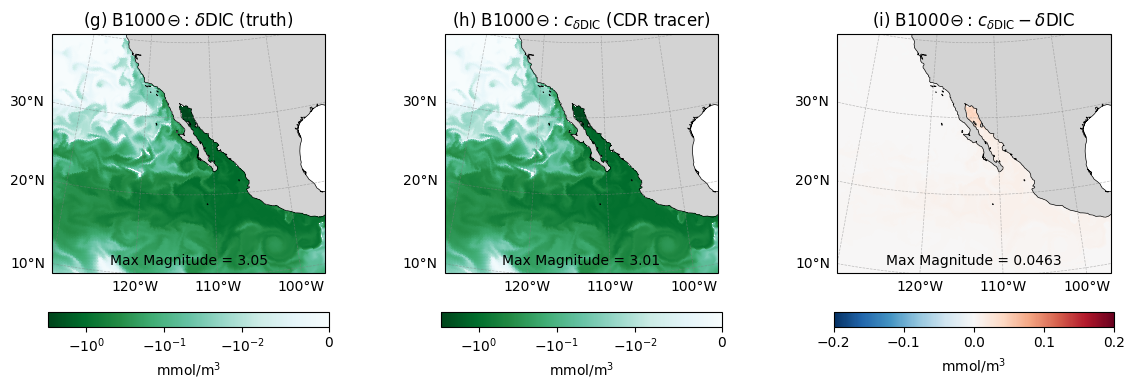

In [33]:
fig = plot_single_amp_panel(
    dor_ctrl, dor_marbl, "BC", "8",
    cdr_type="dor", tracer="dic",
    panel_labels=("g", "h", "i")
)

In [34]:
fig.savefig("figures/deltadic_dor_B1000.png", dpi=300, bbox_inches="tight")

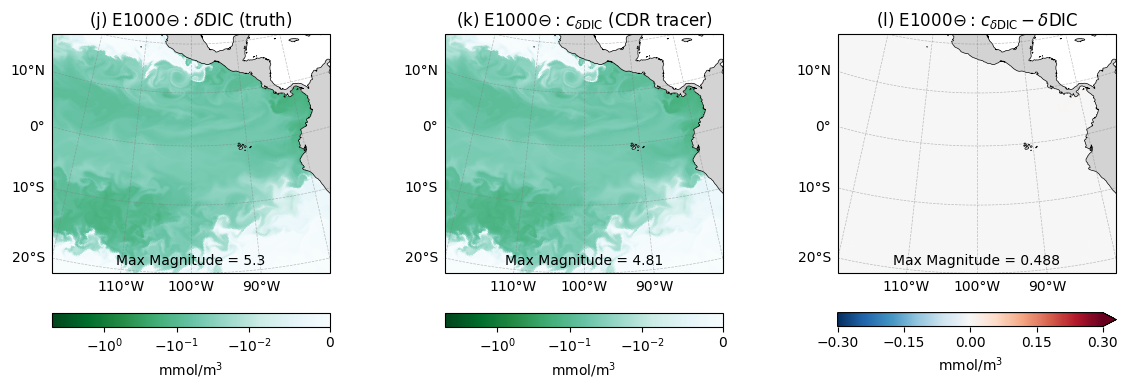

In [35]:
fig = plot_single_amp_panel(
    dor_ctrl, dor_marbl, "EC", "8",
    cdr_type="dor", tracer="dic",
    panel_labels=("j", "k", "l")
)

In [36]:
fig.savefig("figures/deltadic_dor_E1000.png", dpi=300, bbox_inches="tight")

### OAE, ALK

In [37]:
kwargs_diff_override={
    "JP8": dict(vmin=-0.001, vmax=0.001, cmap="RdBu_r"),
    "VI8": dict(vmin=-0.005, vmax=0.005, cmap="RdBu_r"),
    "EC8": dict(vmin=-0.003, vmax=0.003, cmap="RdBu_r"),
    "BC8": dict(vmin=-0.005, vmax=0.005, cmap="RdBu_r")
}

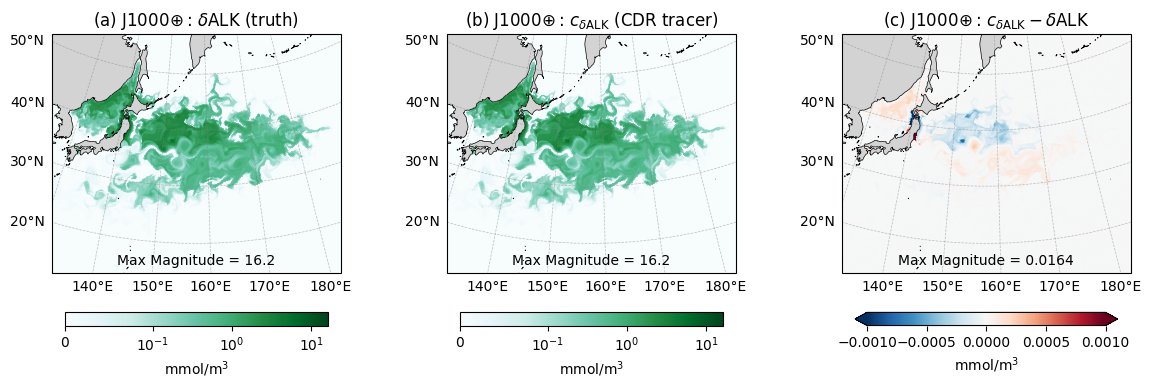

In [38]:
fig = plot_single_amp_panel(
    oae_ctrl, oae_marbl, "JP", "8",
    cdr_type="oae", tracer="alk",
    kwargs_diff_override=kwargs_diff_override
)

In [39]:
fig.savefig("figures/deltaalk_oae_J1000.png", dpi=300, bbox_inches="tight")

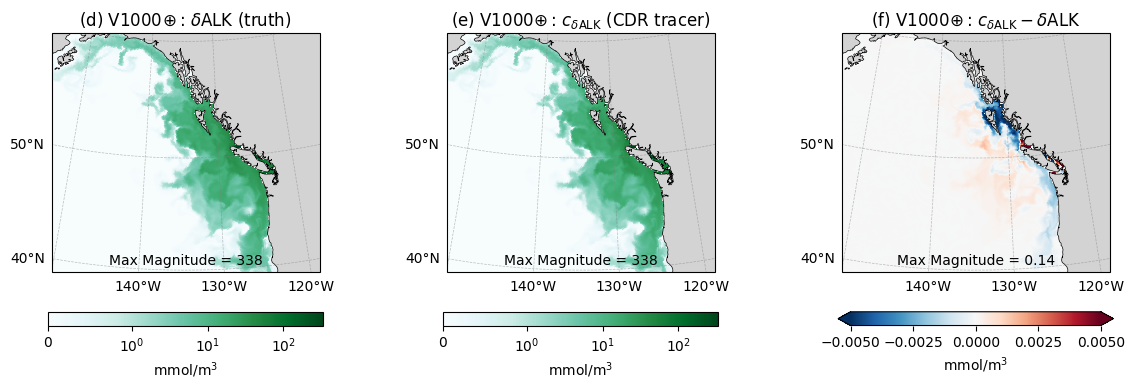

In [40]:
fig = plot_single_amp_panel(
    oae_ctrl, oae_marbl, "VI", "8",
    cdr_type="oae", tracer="alk",
    kwargs_diff_override=kwargs_diff_override,
    panel_labels=("d", "e", "f")
)

In [41]:
fig.savefig("figures/deltaalk_oae_V1000.png", dpi=300, bbox_inches="tight")

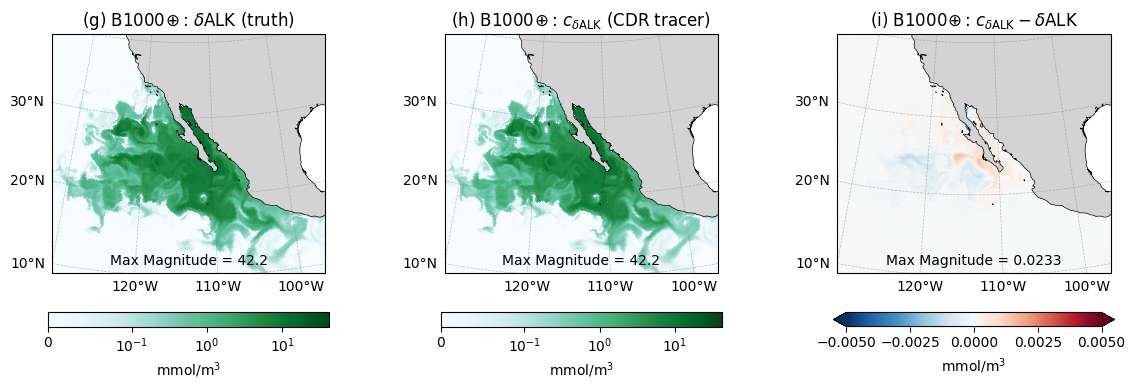

In [42]:
fig = plot_single_amp_panel(
    oae_ctrl, oae_marbl, "BC", "8",
    cdr_type="oae", tracer="alk",
    kwargs_diff_override=kwargs_diff_override,
    panel_labels=("g", "h", "i")
)

In [43]:
fig.savefig("figures/deltaalk_oae_B1000.png", dpi=300, bbox_inches="tight")

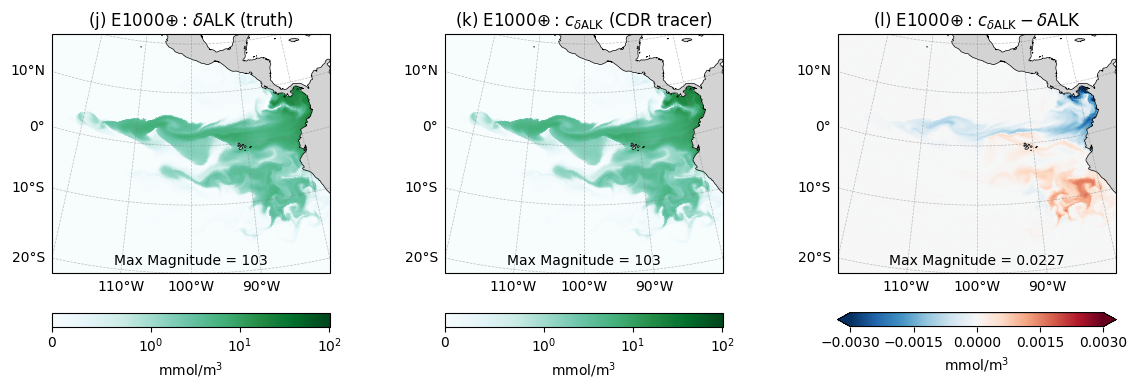

In [44]:
fig = plot_single_amp_panel(
    oae_ctrl, oae_marbl, "EC", "8",
    cdr_type="oae", tracer="alk",
    kwargs_diff_override=kwargs_diff_override,
    panel_labels=("j", "k", "l")
)

In [45]:
fig.savefig("figures/deltaalk_oae_E1000.png", dpi=300, bbox_inches="tight")